# Superstore Project 
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) not just to complete the assignment, but to produce work that directly maps to the five skill areas in the target role. Each section below defines the analysis, the method, the business framing, and the free tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

### Task 2. Descriptive Stats

##### A1. Upload libraries and dataset

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/superstore_clean.parquet')
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

9994 rows, 30 columns


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   object        
 2   Order Date         9994 non-null   datetime64[ns]
 3   Ship Date          9994 non-null   datetime64[ns]
 4   Ship Mode          9994 non-null   object        
 5   Customer ID        9994 non-null   object        
 6   Customer Name      9994 non-null   object        
 7   Segment            9994 non-null   object        
 8   Country            9994 non-null   object        
 9   City               9994 non-null   object        
 10  State              9994 non-null   object        
 11  Postal Code        9994 non-null   int64         
 12  Region             9994 non-null   object        
 13  Product ID         9994 non-null   object        
 14  Category

In [68]:
# Check the dataframe stats
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin,Delivery Days,Year,Quarter,Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,0.120314,3.958175,2015.722233,2.882329,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,-2.750000,0.000000,2014.000000,1.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,0.075000,3.000000,2015.000000,2.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,0.270000,4.000000,2016.000000,3.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,0.362500,5.000000,2017.000000,4.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,0.500000,7.000000,2017.000000,4.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,0.466754,1.747567,1.123555,1.058086,3.284654


#### Task 2.A - Central Tendency of the dataframe

In [69]:
metrics = ['Sales', 'Profit', 'Quantity', 'Discount' ]

central_tendency = pd.DataFrame({
    'Mean': df[metrics].mean(),
    'Median': df[metrics].median(),
    'Mode': df[metrics].mode().iloc[0]
}).round(2)

print(central_tendency)

            Mean  Median   Mode
Sales     229.86   54.49  12.96
Profit     28.66    8.67   0.00
Quantity    3.79    3.00   3.00
Discount    0.16    0.20   0.00


In [70]:
# look at the gap between mean and median
for col in ['Sales', 'Profit']:
    mean = df[col].mean()
    median = df[col].median() # median of a datawet is the value that lies exactly in the middle when the data has been ordered
    print(f"{col}: mean={mean:.2f}, median={median:.2f}, gap={((mean-median)/median*100):.1f}%")

Sales: mean=229.86, median=54.49, gap=321.8%
Profit: mean=28.66, median=8.67, gap=230.7%


The mean transaction value ($229) substantially exceeds the median ($54), indicating a right-skewed distribution driven by a minority of high-value orders. The median is therefore the more representative measure of central tendency for Sales. For Discount, the mode of 0.0 confirms that the majority of transactions carry no discount, with discounted orders representing a distinct subset of the data rather than standard practice

#### Task 2.B - Dispersion

In [71]:
# CV (Coefficient of Variation) is the std as % of the mean
# With it we can compare variability across variables that have different units and scales

dispersion = pd.DataFrame({
    'Min':    df[metrics].min(),
    'Max':    df[metrics].max(),
    'Range':  df[metrics].max() - df[metrics].min(),
    'Std Dev': df[metrics].std(),
    'Variance': df[metrics].var(),
    'IQR':    df[metrics].quantile(0.75) - df[metrics].quantile(0.25),
    'CV (%)': (df[metrics].std() / df[metrics].mean() * 100),  # Coefficient of Variation
}).round(2)

print(dispersion)

              Min       Max     Range  Std Dev   Variance     IQR  CV (%)
Sales        0.44  22638.48  22638.04   623.25  388434.46  192.66  271.14
Profit   -6599.98   8399.98  14999.95   234.26   54877.80   27.64  817.47
Quantity     1.00     14.00     13.00     2.23       4.95    3.00   58.72
Discount     0.00      0.80      0.80     0.21       0.04    0.20  132.17


In [72]:
print("Top discount values by frequency:")
print(df['Discount'].value_counts().head(10).sort_index())

print(f"\nSkewness of Discount: {df['Discount'].skew():.3f}")

Top discount values by frequency:
Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.40     206
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

Skewness of Discount: 1.684


Discount does not follow a continuous distribution. Instead, it takes a small set of discrete values (0%, 20%, 40%, 60%, 80%), with 0% and 20% accounting for the vast majority of transactions. This discrete, tiered structure indicates company-defined promotional levels rather than individually negotiated discounts. Mean and median both equal 0.2, reflecting the dominance of the 20% tier among discounted orders.

* Sales and Profit display high coefficients of variation (appr. 271% and 817% respectively), indicating substantial dispersion relative to their averages values.
* This reflects the heterogeneous nature of the transactions mix: from a small office supply orders to large furniture purchases, with ranges from very small purchases ($0.44) to large orders exceding $22,000.
* Profitability is even more volatile, with values spanning from losses of nearly $6,600 to gains over $8,400.
* The interquartile range (IQR) for Profit ($20.67) suggests that the middle 50% of transactions generate relatively modest profits, while the extreme tails capture unusually profitable orders as well as significant losses, likely influenced by heavy discounting and differences in product mix.
* The high variability in both Sales and Profit indicates that aggregate performance is driven by a relatively small number of exceptionally large or highly profitable transactions.

In [73]:
print(f"Profit CV: {df['Profit'].std() / df['Profit'].mean() * 100:.0f}%")
print(f"For comparison, Sales CV: {df['Sales'].std() / df['Sales'].mean() * 100:.0f}%")
print(f"\nProfit ranges from ${df['Profit'].min():,.0f} to ${df['Profit'].max():,.0f}")
print(f"But 50% of orders generate profit between ${df['Profit'].quantile(0.25):,.0f} and ${df['Profit'].quantile(0.75):,.0f}")

Profit CV: 817%
For comparison, Sales CV: 271%

Profit ranges from $-6,600 to $8,400
But 50% of orders generate profit between $2 and $29


#### Task 2.C - Shape of Distributions

Histograms with KDE
* A histogram with a Kernel Density Estimate (KDE) overlays a smooth, continuous probability curve onto a discrete bar chart

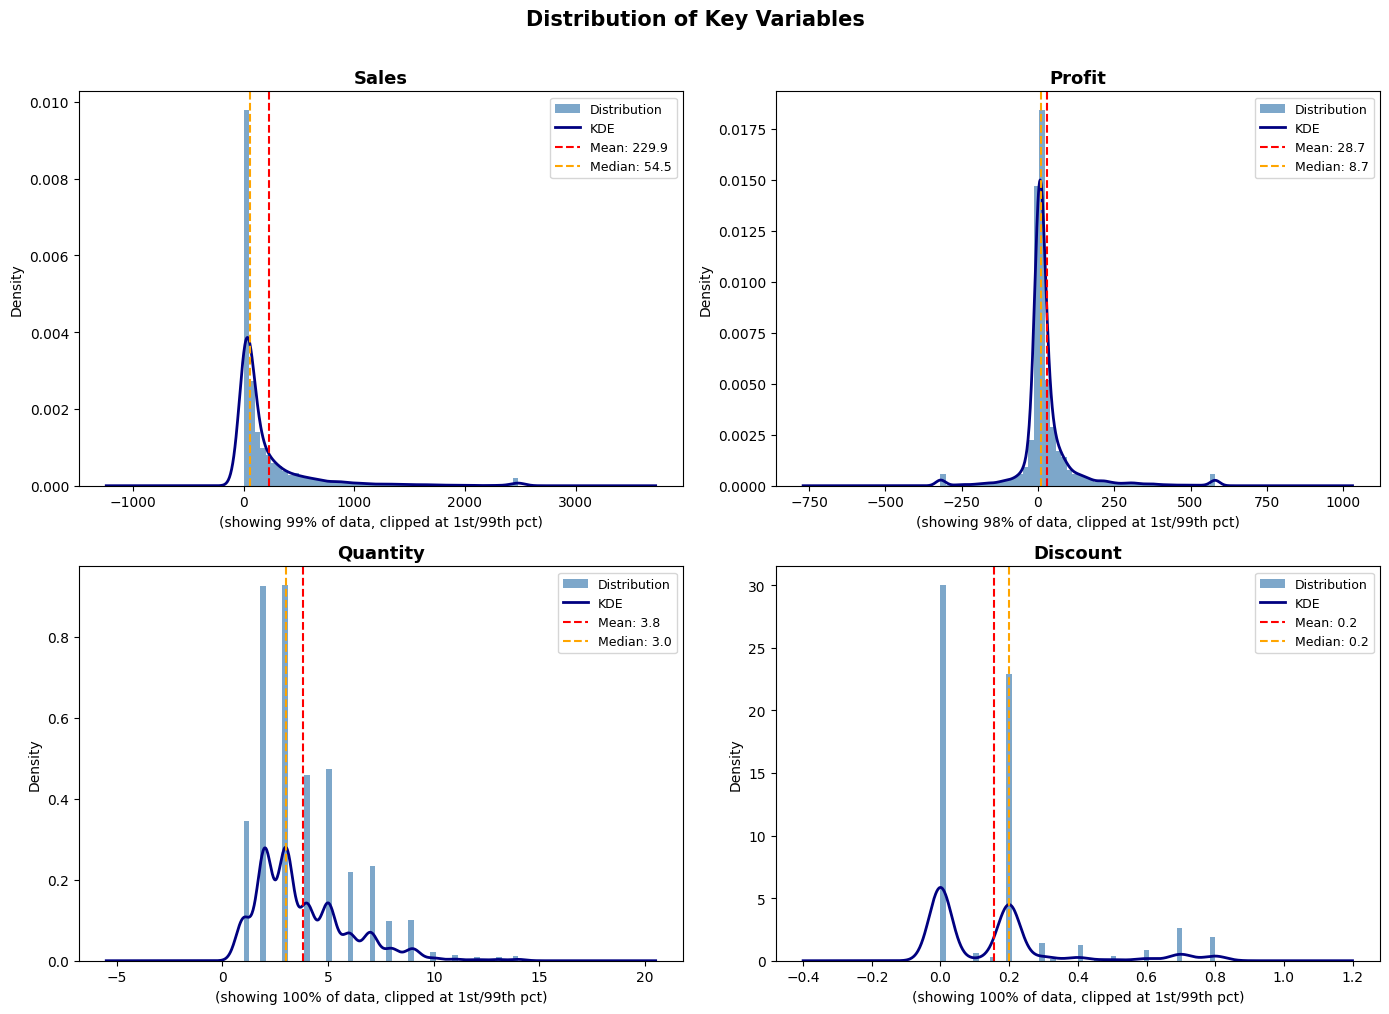

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define display limits per variable (clip outliers for readability)
clip_limits = {
    'Sales':    (0, df['Sales'].quantile(0.99)),
    'Profit':   (df['Profit'].quantile(0.01), df['Profit'].quantile(0.99)),
    'Quantity': (0, 15),
    'Discount': (-0.05, 0.85)
}

for i, col in enumerate(metrics):
    lo, hi = clip_limits[col]
    data = df[col].clip(lo, hi)

    axes[i].hist(data, bins=50, color='steelblue', alpha=0.7, 
                 density=True, label='Distribution')
    data.plot.kde(ax=axes[i], color='navy', linewidth=2, label='KDE')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', 
                    linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', 
                    linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

    # Note in subtitle if clipped
    pct_shown = ((df[col] >= lo) & (df[col] <= hi)).mean() * 100
    axes[i].set_xlabel(f'(showing {pct_shown:.0f}% of data, clipped at 1st/99th pct)')

plt.suptitle('Distribution of Key Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/images/02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

##### C1. Skeness and Kurtosis

In [75]:
shape = pd.DataFrame({
    'Skewness':         df[metrics].skew(),
    'Kurtosis':         df[metrics].kurtosis(),
    'Interpretation':   [
        'Right-skewed - few very large orders',
        'Right-skewed - losses in tail',
        'Slightly righ-skiwed - bulk orders',
        'Left-skewed - most orders have 0% or low discount'
    ]
}).round(3)

print(shape)

          Skewness  Kurtosis  \
Sales       12.973   305.312   
Profit       7.561   397.189   
Quantity     1.279     1.992   
Discount     1.684     2.410   

                                             Interpretation  
Sales                  Right-skewed - few very large orders  
Profit                        Right-skewed - losses in tail  
Quantity                 Slightly righ-skiwed - bulk orders  
Discount  Left-skewed - most orders have 0% or low discount  


* Sales — strongly right-skewed. The clearest signal: mean ($229.9) is more than 4× the median ($54.5). That gap only happens when a long right tail pulls the mean upward. Most transactions are small, but a few very large orders distort the average.
* Profit — strongly right-skewed, but with a heavy left tail too. Mean ($28.7) > median ($8.7) confirms right skew. However, Profit is unusual because it also has extreme negative values. The skewness number will be positive, but the chart shows it's almost symmetric visually — just with very fat tails on both sides. The technical term is leptokurtic: thin peak, heavy tails.
* Quantity — mildly right-skewed. Mean (3.8) slightly above median (3.0). Most orders are 1–5 units, with a thin tail trailing to 14. The skew is modest.
* Discount — approximately symmetric, but multimodal. Mean = Median = 0.2, so skewness will be close to zero. This doesn't mean the distribution is normal — it's discrete with five distinct spikes. Symmetric ≠ normal.

In [76]:
from scipy.stats import kurtosis

kurtosis(df["Profit"], fisher=False)

# If kurtosis > 3 (or excess kurtosis > 0), then the claim is statistically supported.

np.float64(399.9892286014973)

Summary: 
* Sales and Profit are both strongly positively skewed, as evidenced by the mean exceeding the median and the presence of long right tails. 
* This indicates that a relatively small number of high-value transactions exert a disproportionate influence on average performance ( Profit exhibits leptokurtosis). 
* Profit additionally shows a pronounced central concentration with substantial tails on both the positive and negative sides, reflecting the coexistence of highly profitable orders and significant losses within the portfolio. 
* Quantity is only mildly right-skewed, consistent with the predominance of small orders.
* Discount is distinctly non-normal and multimodal, with discrete peaks at common discount levels that reflect a structured pricing policy rather than a naturally occurring statistical distribution. 
* Given the strong skewness and outliers in Sales and Profit, the median provides a more representative measure of typical transaction performance than the mean

#### Task 2.D - Comparative Analysis

##### D1. Comparison 1 - By Region

In [77]:
region_stats = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Order_Count=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2)

region_stats['Profit_per_Order'] = (region_stats['Total_Profit'] / region_stats['Order_Count']).round(2)
region_stats = region_stats.sort_values('Total_Profit', ascending=False)
print(region_stats)

         Total_Sales  Total_Profit  Avg_Profit_Margin  Order_Count  \
Region                                                               
West       725457.82     108418.45               0.22         1611   
East       678781.24      91522.78               0.17         1401   
South      391721.90      46749.43               0.16          822   
Central    501239.89      39706.36              -0.10         1175   

         Avg_Discount  Profit_per_Order  
Region                                   
West             0.11             67.30  
East             0.15             65.33  
South            0.15             56.87  
Central          0.24             33.79  


In [78]:
# creating a custom palette
colors = ['#1192AA','#00B8C0', '#73D4D3', '#90F2F0']

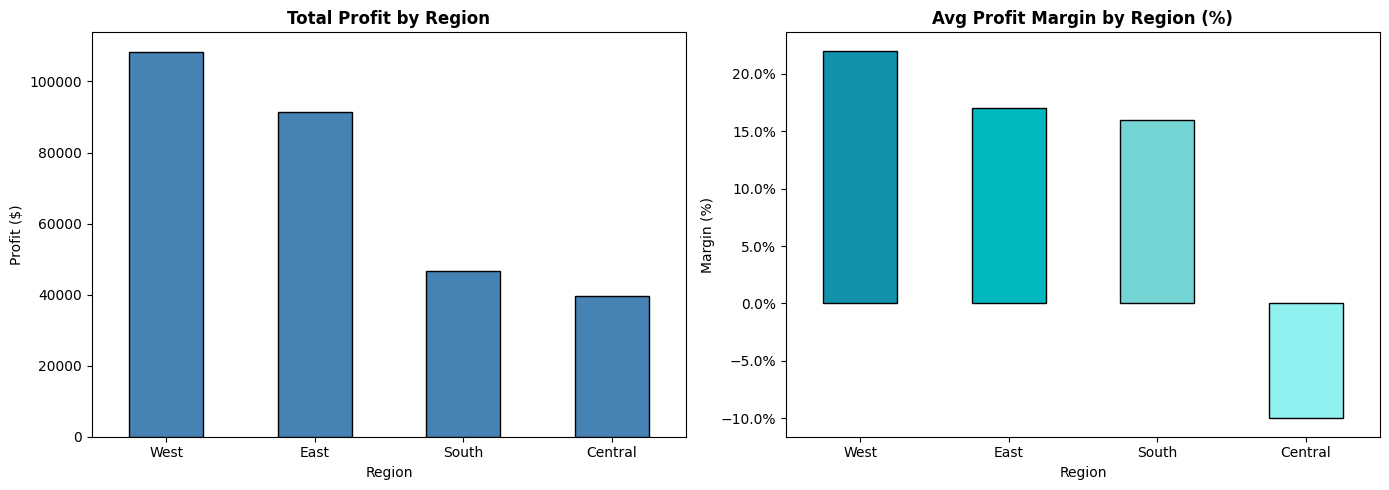

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total profit by region
region_stats['Total_Profit'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Profit by Region', fontweight='bold')
axes[0].set_ylabel('Profit ($)')
axes[0].tick_params(axis='x', rotation=0)

# Avg profit margin by region
(region_stats['Avg_Profit_Margin'] * 100).plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Avg Profit Margin by Region (%)', fontweight='bold')
axes[1].set_ylabel('Margin (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../output/images/02_region_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Total Profit by State/Region Map

In [80]:
import os
import plotly.graph_objects as go

state_profit = df.groupby('State_abb')['Profit'].sum().reset_index()

fig = go.Figure(data=go.Choropleth(
    locations=state_profit['State_abb'],
    z=state_profit['Profit'],
    locationmode='USA-states',
    colorscale='tropic_r', zmin=-30000, zmax=30000
))

fig.update_layout(
    font=dict(size=14),
    title={'text': "Total Profit by State", 'y': 0.95, 'x': 0.5},
    geo_scope='usa',
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/02_profit_by_state_map.png', scale=2)

##### D2. Comparison 2 - By Customer Segment

In [81]:
segment_stats = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Unique_Customers=('Customer ID', 'nunique'),
    Avg_Order_Value=('Sales', 'mean'),
    Avg_Discount=('Discount', 'mean')
).round(2)

segment_stats['Revenue_Per_Customer'] = (segment_stats['Total_Sales'] / segment_stats['Unique_Customers']).round(2)
print(segment_stats.sort_values('Total_Profit', ascending=False))

             Total_Sales  Total_Profit  Avg_Profit_Margin  Unique_Customers  \
Segment                                                                       
Consumer      1161401.34     134119.21               0.11               409   
Corporate      706146.37      91979.13               0.12               236   
Home Office    429653.15      60298.68               0.14               148   

             Avg_Order_Value  Avg_Discount  Revenue_Per_Customer  
Segment                                                           
Consumer              223.73          0.16               2839.61  
Corporate             233.82          0.16               2992.15  
Home Office           240.97          0.15               2903.06  


In [82]:
# Frequency of orders by Region
fig = px.bar(
    x=df['Ship Mode'].value_counts().index,
    y=df['Ship Mode'].value_counts(),
    color=df['Ship Mode'].value_counts().index,
    template='simple_white',
    color_discrete_sequence=colors
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Number of Orders",
    showlegend=False,
    font=dict(size=14),
    title={'text': "Frequency of Orders by Shipping Modes", 'y': 0.95, 'x': 0.5}
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/02_shipping_mode_frequency.png', scale=2)

##### D3. Comparison 3 - By Product Category

In [83]:
fig = px.bar(x = df['Sub-Category'].value_counts().index, y = df['Sub-Category'].value_counts(),
             template = 'simple_white', color_discrete_sequence = colors)

#Set Title and x/y axis labels
fig.update_layout(
    xaxis_title="Sub-Category",
    yaxis_title="Number of Orders",
    font = dict(
            size = 14
            ),    
    title={
        'text': "Frequency of Orders by Sub-Category",
        'y':0.95,
        'x':0.5
        }
    )

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/02_frequency_orders_by_subcategory.png', scale=2)

In [84]:
cat_stats = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean')
).round(2).sort_values('Avg_Margin')

print(cat_stats)

                              Total_Sales  Total_Profit  Avg_Margin  \
Category        Sub-Category                                          
Office Supplies Binders         203412.73      30221.76       -0.20   
                Appliances      107532.16      18138.01       -0.16   
Furniture       Tables          206965.53     -17725.48       -0.15   
                Bookcases       114880.00      -3472.56       -0.13   
Technology      Machines        189238.63       3384.76       -0.07   
Furniture       Chairs          328449.10      26590.17        0.04   
Office Supplies Storage         223843.61      21278.83        0.09   
                Supplies         46673.54      -1189.10        0.11   
Technology      Phones          330007.05      44515.73        0.12   
Furniture       Furnishings      91705.16      13059.14        0.14   
Technology      Accessories     167380.32      41936.64        0.22   
Office Supplies Art              27118.79       6527.79        0.25   
      

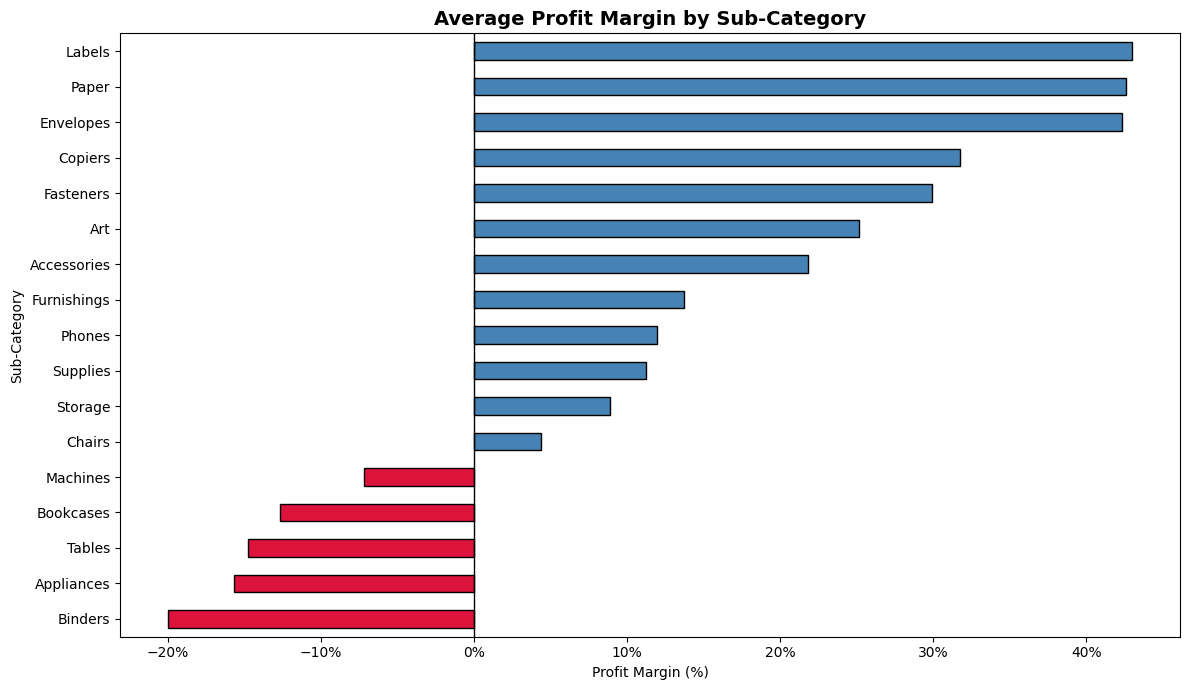

In [85]:
# Margin by sub-category — sorted, colour-coded
sub_margin = df.groupby('Sub-Category')['Profit Margin'].mean().sort_values()

colors = ['crimson' if x < 0 else 'steelblue' for x in sub_margin.values]

fig, ax = plt.subplots(figsize=(12, 7))
sub_margin.mul(100).plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Average Profit Margin by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit Margin (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('../output/images/02_margin_by_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()

##### D4. Comparison 4 - By Shipping Mode

In [87]:
ship_stats = df.groupby('Ship Mode').agg(
    Order_Count=('Order ID', 'nunique'),
    Avg_Delivery_Days=('Delivery Days', 'mean'),
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit_Margin=('Profit Margin', 'mean')
).round(2).sort_values('Avg_Delivery_Days')

print(ship_stats)

                Order_Count  Avg_Delivery_Days  Avg_Sales  Avg_Profit_Margin
Ship Mode                                                                   
Same Day                264               0.04     236.40               0.14
First Class             787               2.18     228.50               0.12
Second Class            964               3.24     236.09               0.15
Standard Class         2994               5.01     227.58               0.11


In [88]:
summary = pd.DataFrame({
    'Dimension': ['Region', 'Region', 'Segment', 'Segment', 
                  'Category', 'Category', 'Ship Mode'],
    'Group': ['West', 'Central', 'Corporate', 'Consumer', 
              'Technology', 'Furniture', 'Same Day'],
    'Finding': [
        'Highest total profit',
        'Lowest profit margin',
        'Highest revenue per customer',
        'Highest order volume',
        'Highest average margin',
        'Contains loss-making sub-categories (Tables, Bookcases)',
        'Fastest delivery but smallest order volume'
    ]
})
print(summary.to_string(index=False))

Dimension      Group                                                 Finding
   Region       West                                    Highest total profit
   Region    Central                                    Lowest profit margin
  Segment  Corporate                            Highest revenue per customer
  Segment   Consumer                                    Highest order volume
 Category Technology                                  Highest average margin
 Category  Furniture Contains loss-making sub-categories (Tables, Bookcases)
Ship Mode   Same Day              Fastest delivery but smallest order volume


##### D5. Comparison 5: By Frequency of Orders: Shipping Modes

In [89]:
# creating a custom palette
colors = ['#1192AA','#00B8C0', '#73D4D3', '#90F2F0']

In [90]:
import os
import plotly.express as px

fig = px.bar(
    x=df['Ship Mode'].value_counts().index,
    y=df['Ship Mode'].value_counts(),
    color=df['Ship Mode'].value_counts().index,
    template='simple_white',
    color_discrete_sequence=colors
)

fig.update_layout(
    xaxis_title="Shipping Mode",
    yaxis_title="Number of Orders",
    showlegend=False,
    font=dict(size=14),
    title={'text': "Frequency of Orders by Shipping Modes", 'y': 0.95, 'x': 0.5}
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/02_shipping_mode_frequency.png', scale=2)

##### D6. Comparison 6: Sales & Profit over Time (2014-2028)

In [94]:
# create timeseries table, group by order date and sum sales and profit
data_timeseries = df.copy()
data_timeseries = data_timeseries[['Order Date', 'Sales', 'Profit']].groupby('Order Date', as_index = False).sum()

# convert order date column to timestemp datatype
data_timeseries['Order Date'] = pd.to_datetime(data_timeseries['Order Date'])

# sort by date
data_timeseries = data_timeseries.sort_values(by = 'Order Date')

In [97]:
data_timeseries['Profitable'] = data_timeseries['Profit'] / abs(data_timeseries['Profit'])
data_timeseries['Profitable'] = data_timeseries['Profitable'].fillna(0)
data_timeseries['Profitable'] = data_timeseries['Profitable'].astype(int)

In [98]:
# Sales & Profit over time (2014-2018)
fig = go.Figure(go.Scatter( 
                 x = data_timeseries['Order Date'],
                 y = data_timeseries['Profit'],
                 mode='markers',
                 marker=dict(
                         size = data_timeseries['Sales']/500,
                         color= data_timeseries['Profitable'])
             )
               )
# layout
fig.update_layout(
    yaxis_title = "Profit",
    xaxis_title="Date",
    showlegend = False,
    font = dict(
            size = 14
            ),    
    title={
        'text': "Sales & Profit over Time Period(2014-2018)",
        'y':0.95,
        'x':0.5
        },
    template = 'simple_white',
)

fig.show()
os.makedirs('../output/images', exist_ok=True)
fig.write_image('../output/images/02_sales_profit_over_time.png', scale=2)

##### D7. Save the comparison tables
* regions_stats, segment_stats, cat_stats, ship_stats

In [100]:
import os
os.makedirs('../output/kpis', exist_ok=True)

region_stats.to_csv('../output/kpis/region_stats.csv')
segment_stats.to_csv('../output/kpis/segment_stats.csv')
cat_stats.to_csv('../output/kpis/category_stats.csv')
ship_stats.to_csv('../output/kpis/shipping_stats.csv')

print("Saved:")
for f in os.listdir('../output/kpis'):
    print(f"  output/kpis/{f}")

Saved:
  output/kpis/region_stats.csv
  output/kpis/shipping_stats.csv
  output/kpis/segment_stats.csv
  output/kpis/category_stats.csv
